In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import sys
!{sys.executable} -m pip install --upgrade statsmodels

In [3]:
# importing the needed libraries to analyse the dataset.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('C:\\Users\\HP\\Downloads\\Chocolate Sales (2).csv')
#reading-in the csv dataset

In [5]:
# dataset overview: rows,columns,data types,memory usage,basic statistics.

In [6]:
df.head()          # first 5 rows

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,04/01/2022,"$5,320.00",180
1,Van Tuxwell,India,85% Dark Bars,01/08/2022,"$7,896.00",94
2,Gigi Bohling,India,Peanut Butter Cubes,07/07/2022,"$4,501.00",91
3,Jan Morforth,Australia,Peanut Butter Cubes,27/04/2022,"$12,726.00",342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,24/02/2022,"$13,685.00",184


In [7]:
df.tail()             #last 5 rows

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
3277,Karlen McCaffrey,Australia,Spicy Special Slims,17/05/2024,"$5,303.58",354
3278,Jehu Rudeforth,USA,White Choc,07/06/2024,"$7,339.32",121
3279,Ches Bonnell,Canada,Organic Choco Syrup,26/07/2024,$616.09,238
3280,Dotty Strutley,India,Eclairs,28/07/2024,"$2,504.62",397
3281,Karlen McCaffrey,India,70% Dark Bites,23/05/2024,"$5,915.87",355


In [8]:
df.shape                     # rows & columns counmns count

(3282, 6)

In [9]:
df.columns                   # column names 

Index(['Sales Person', 'Country', 'Product', 'Date', 'Amount',
       'Boxes Shipped'],
      dtype='object')

In [10]:
df.dtypes                     # data types

Sales Person     object
Country          object
Product          object
Date             object
Amount           object
Boxes Shipped     int64
dtype: object

In [11]:
df.info()                      # overview of all columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3282 entries, 0 to 3281
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Sales Person   3282 non-null   object
 1   Country        3282 non-null   object
 2   Product        3282 non-null   object
 3   Date           3282 non-null   object
 4   Amount         3282 non-null   object
 5   Boxes Shipped  3282 non-null   int64 
dtypes: int64(1), object(5)
memory usage: 154.0+ KB


In [12]:
df.index

RangeIndex(start=0, stop=3282, step=1)

In [13]:
df.isna()                      # checking for missing values

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False
...,...,...,...,...,...,...
3277,False,False,False,False,False,False
3278,False,False,False,False,False,False
3279,False,False,False,False,False,False
3280,False,False,False,False,False,False


In [14]:
df.isna().sum()                # sum of missing values

Sales Person     0
Country          0
Product          0
Date             0
Amount           0
Boxes Shipped    0
dtype: int64

In [15]:
df.duplicated().sum()            # checking for duplicate rows

0

In [16]:
df.describe()                             # mean, min, max, std for numbers

,Boxes Shipped
count,3282.000000
mean,164.666971
std,124.024736
min,1.000000
25%,71.000000
50%,137.000000
75%,232.000000
max,778.000000


In [17]:
# changing date to datetime

df['Date'] = pd.to_datetime(df['Date'],dayfirst = True)          

df.set_index('Date', inplace=True)

In [18]:
df['Amount'] = df['Amount'].str.replace('$','', regex = False)         # Removes the $ sign → "$1,200" becomes "1,200"
df['Amount'] = df['Amount'].str.replace(',','', regex = False)         # Removes the comma → "1,200" becomes "1200"

In [19]:
df['Amount'] = df['Amount'].astype(float)        # converts to number

In [20]:
df.head()                           # first 5 rows again

,Sales Person,Country,Product,Amount,Boxes Shipped
Date,,,,,
2022-01-04,Jehu Rudeforth,UK,Mint Chip Choco,5320.0,180
2022-08-01,Van Tuxwell,India,85% Dark Bars,7896.0,94
2022-07-07,Gigi Bohling,India,Peanut Butter Cubes,4501.0,91
2022-04-27,Jan Morforth,Australia,Peanut Butter Cubes,12726.0,342
2022-02-24,Jehu Rudeforth,UK,Peanut Butter Cubes,13685.0,184


In [21]:
df.tail()                     # last 5 rows again

,Sales Person,Country,Product,Amount,Boxes Shipped
Date,,,,,
2024-05-17,Karlen McCaffrey,Australia,Spicy Special Slims,5303.58,354
2024-06-07,Jehu Rudeforth,USA,White Choc,7339.32,121
2024-07-26,Ches Bonnell,Canada,Organic Choco Syrup,616.09,238
2024-07-28,Dotty Strutley,India,Eclairs,2504.62,397
2024-05-23,Karlen McCaffrey,India,70% Dark Bites,5915.87,355


In [22]:
df.info()                       # overview of all columns again

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3282 entries, 2022-01-04 to 2024-05-23
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Sales Person   3282 non-null   object 
 1   Country        3282 non-null   object 
 2   Product        3282 non-null   object 
 3   Amount         3282 non-null   float64
 4   Boxes Shipped  3282 non-null   int64  
dtypes: float64(1), int64(1), object(3)
memory usage: 153.8+ KB


In [23]:
df.isna().sum()                          # missing values

Sales Person     0
Country          0
Product          0
Amount           0
Boxes Shipped    0
dtype: int64

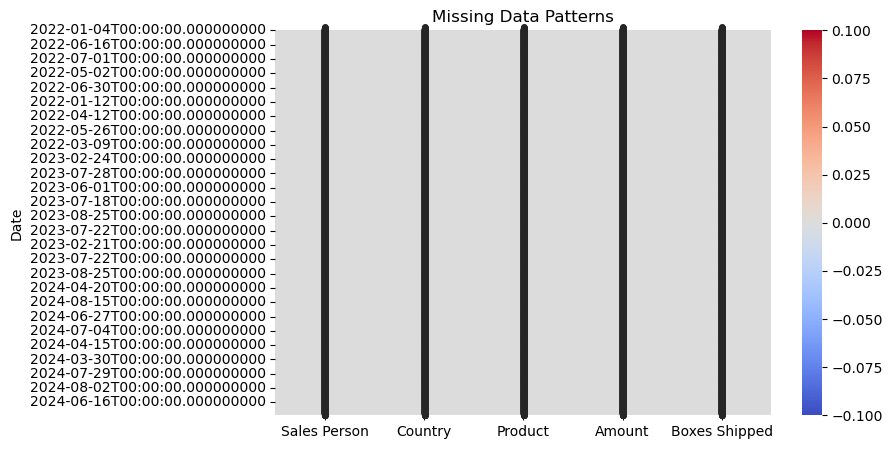

In [24]:
# heatmap for Missing Data Patterns

plt.figure(figsize = (8,5))
sns.heatmap(df.isnull() , cmap = 'coolwarm', annot=True)
plt.title('Missing Data Patterns')            
plt.show()

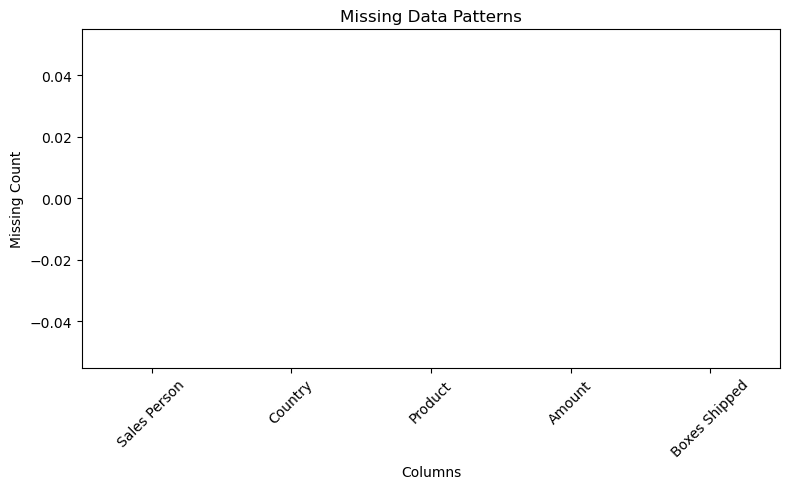

In [25]:
# heatmap for Missing Data Patterns

plt.figure(figsize=(8, 5))
sns.barplot(df.isnull().sum())
plt.title('Missing Data Patterns')
plt.xlabel('Columns')
plt.ylabel('Missing Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

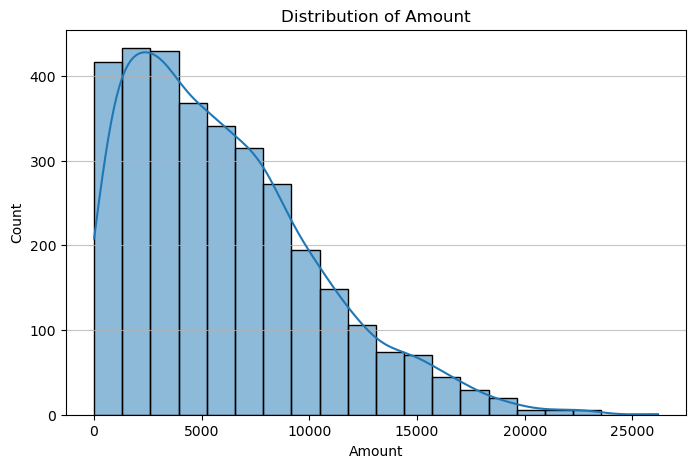

In [26]:
# Histogram plot showing the Distribution of Sales Amount

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='Amount', kde=True, bins=20)
plt.title('Distribution of Amount')
plt.xlabel('Amount')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [27]:
df['Amount'].describe()                     # mean, min, max, std for the sales amount

count     3282.000000
mean      6030.338775
std       4393.980200
min          7.000000
25%       2521.495000
50%       5225.500000
75%       8556.842500
max      26170.950000
Name: Amount, dtype: float64

In [28]:
# Checking skewness and kurtosis of Amount

print('Skewness:', df['Amount'].skew())
print('Kurtosis:', df['Amount'].kurt())

Skewness: 0.9169938620840846
Kurtosis: 0.579081157101057


In [29]:
# Finding the maximum sales amount and its corresponding product

Max_Amount = df['Amount'].max()
print (Max_Amount)
highest_priced_chocolate = df[df['Amount'] == Max_Amount]
highest_priced_chocolate

26170.95


,Sales Person,Country,Product,Amount,Boxes Shipped
Date,,,,,
2024-01-27,Ches Bonnell,India,Peanut Butter Cubes,26170.95,224


In [30]:
# Finding the minimum sales amount and its corresponding product

Min_Amount = df['Amount'].min()
print (Min_Amount)
lowest_priced_chocolate = df[df['Amount'] == Min_Amount]
lowest_priced_chocolate

7.0


,Sales Person,Country,Product,Amount,Boxes Shipped
Date,,,,,
2022-03-07,Gunar Cockshoot,UK,99% Dark & Pure,7.0,84
2022-04-12,Kaine Padly,New Zealand,Smooth Sliky Salty,7.0,518


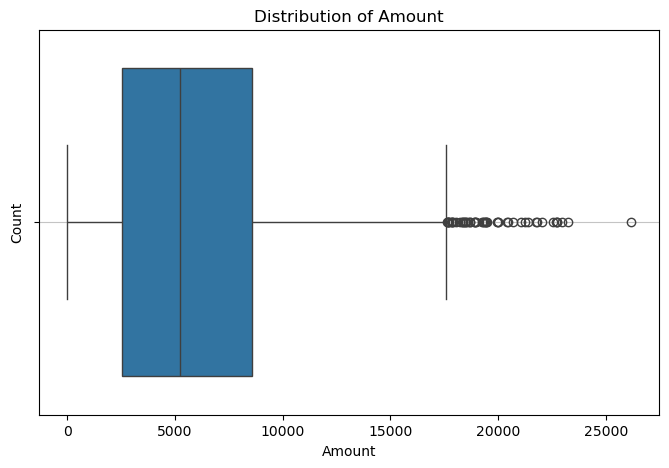

In [31]:
# Boxplot showing the Distribution of Sales Amount

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Amount')
plt.title('Distribution of Amount')
plt.xlabel('Amount')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [32]:
# checking the price per product

Price_per_Product = df.groupby('Product')['Amount'].sum().sort_values(ascending=False).head()
Price_per_Product

Product
Smooth Sliky Salty     1120201.09
50% Dark Bites         1087659.35
White Choc             1054257.00
Peanut Butter Cubes    1036591.09
Eclairs                 996947.96
Name: Amount, dtype: float64

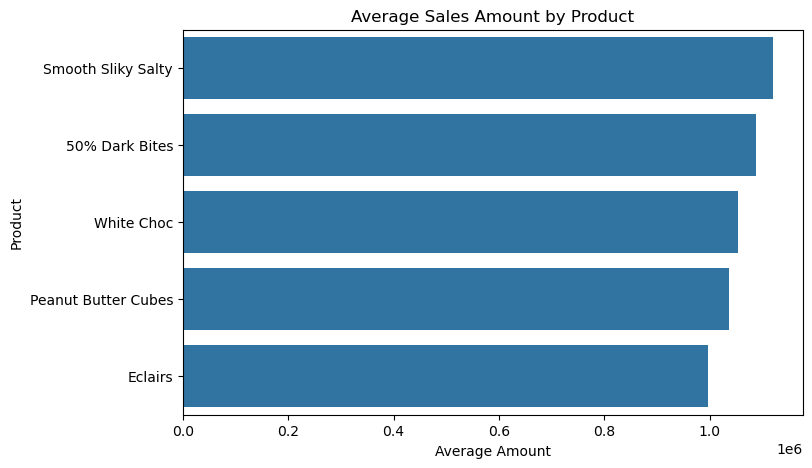

In [33]:
# Barchart showing the top 5 product per price 

plt.figure(figsize=(8, 5))
sns.barplot(x=Price_per_Product.values, y=Price_per_Product.index)
plt.title('Average Sales Amount by Product')
plt.xlabel('Average Amount')
plt.ylabel('Product')
plt.show()

In [34]:
# Total revenue per country

Country_per_Amount = df.groupby('Country')['Amount'].sum().sort_values(ascending=False).head()
Country_per_Amount

Country
Australia    3646444.35
UK           3365388.90
India        3343730.83
USA          3313858.09
Canada       3078495.65
Name: Amount, dtype: float64

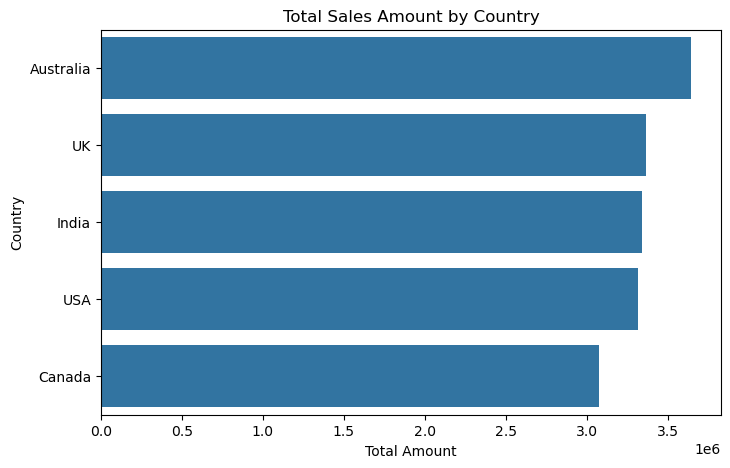

In [35]:
# Barchart showing the Total revenue per country

plt.figure(figsize=(8, 5))
sns.barplot(x=Country_per_Amount.values, y=Country_per_Amount.index)
plt.title('Total Sales Amount by Country')
plt.xlabel('Total Amount')
plt.ylabel('Country')
plt.show()

In [36]:
# identifying the best performing salesperson

Sales_Person_per_Amount = df.groupby('Sales Person')['Amount'].sum().sort_values(ascending=False).head()
Sales_Person_per_Amount

Sales Person
Ches Bonnell       1022599.96
Oby Sorrel         1017204.12
Madelene Upcott    1010028.72
Kelci Walkden      1002929.10
Brien Boise         997326.48
Name: Amount, dtype: float64

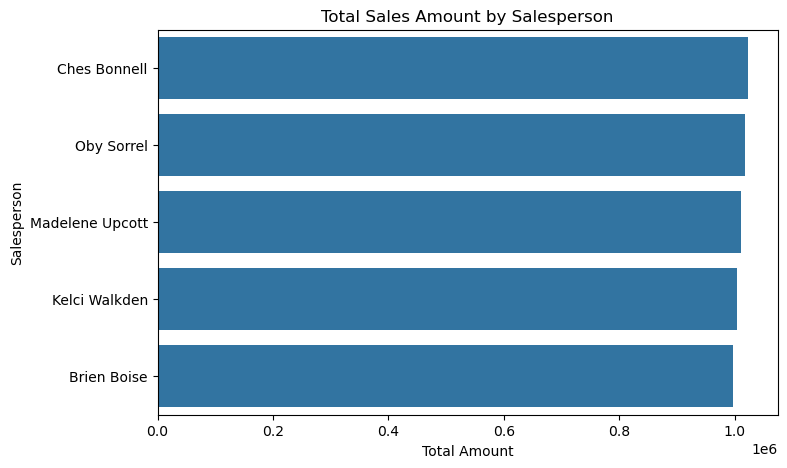

In [37]:
# Barchart showing the Best performing salesperson

plt.figure(figsize=(8, 5))
sns.barplot(x=Sales_Person_per_Amount.values, y=Sales_Person_per_Amount.index)
plt.title('Total Sales Amount by Salesperson')
plt.xlabel('Total Amount')
plt.ylabel('Salesperson')
plt.show()

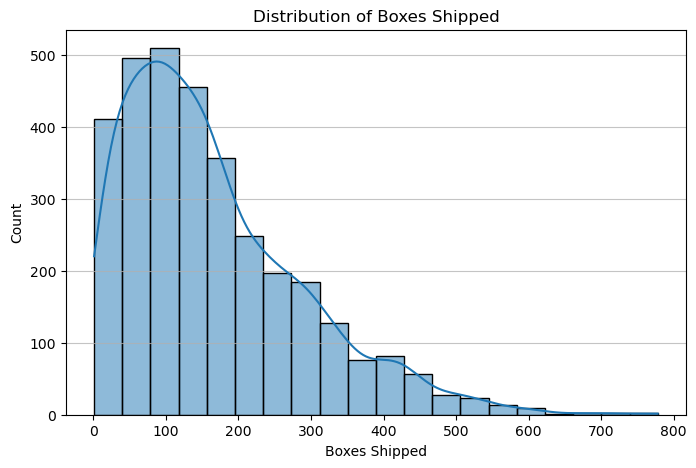

In [38]:
# Histogram plot showing the Distribution of Boxes Shipped

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='Boxes Shipped', kde=True, bins=20)
plt.title('Distribution of Boxes Shipped')
plt.xlabel('Boxes Shipped')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [39]:
df['Boxes Shipped'].describe()              # mean, min, max, std for numbers

count    3282.000000
mean      164.666971
std       124.024736
min         1.000000
25%        71.000000
50%       137.000000
75%       232.000000
max       778.000000
Name: Boxes Shipped, dtype: float64

In [40]:
# Checking skewness and kurtosis of Boxes Shipped

print('Skewness:', df['Boxes Shipped'].skew())
print('Kurtosis:', df['Boxes Shipped'].kurt())

Skewness: 1.1308937555944618
Kurtosis: 1.2680745414221288


In [41]:
# Finding the maximum Boxes Shipped and its corresponding product

Max_Boxes_Shipped = df['Boxes Shipped'].max()
print (Max_Boxes_Shipped)
highest_Boxes_Shipped = df[df['Boxes Shipped'] == Max_Boxes_Shipped]
highest_Boxes_Shipped

778


,Sales Person,Country,Product,Amount,Boxes Shipped
Date,,,,,
2024-01-17,Karlen McCaffrey,Australia,50% Dark Bites,7642.94,778


In [42]:
# Finding the minimum Boxes Shipped and its corresponding product

Min_Boxes_Shipped = df['Boxes Shipped'].min()
print (Min_Boxes_Shipped)
highest_Boxes_Shipped = df[df['Boxes Shipped'] == Min_Boxes_Shipped]
highest_Boxes_Shipped

1


,Sales Person,Country,Product,Amount,Boxes Shipped
Date,,,,,
2022-03-29,Barr Faughny,Canada,White Choc,4291.00,1
2023-03-29,Barr Faughny,Canada,White Choc,4692.36,1
2024-03-29,Barr Faughny,Canada,White Choc,4590.46,1


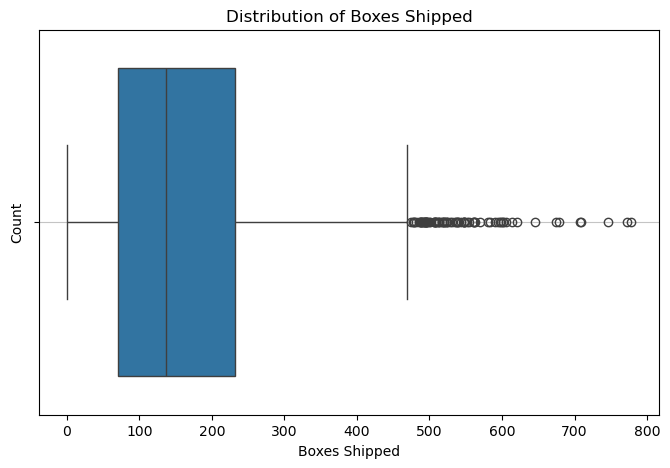

In [43]:
# Boxplot showing the Distribution of Boxes Shipped

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Boxes Shipped')
plt.title('Distribution of Boxes Shipped')
plt.xlabel('Boxes Shipped')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.75)
plt.show()

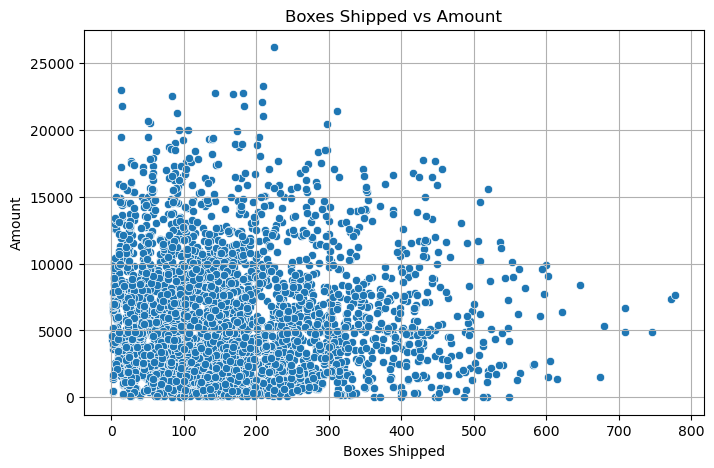

In [44]:
# Scatterplot showing the Distribution of Boxes Shipped

plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Boxes Shipped", y="Amount")
plt.title("Boxes Shipped vs Amount")
plt.xlabel("Boxes Shipped")
plt.ylabel("Amount")
plt.grid(True)
plt.show()

In [45]:
# checking the Boxes Shipped per product

Shipped_Product = df.groupby('Product')['Boxes Shipped'].sum().sort_values(ascending=False).head()
Shipped_Product

Product
50% Dark Bites          29810
Smooth Sliky Salty      26969
Eclairs                 26678
Spicy Special Slims     26662
Caramel Stuffed Bars    26576
Name: Boxes Shipped, dtype: int64

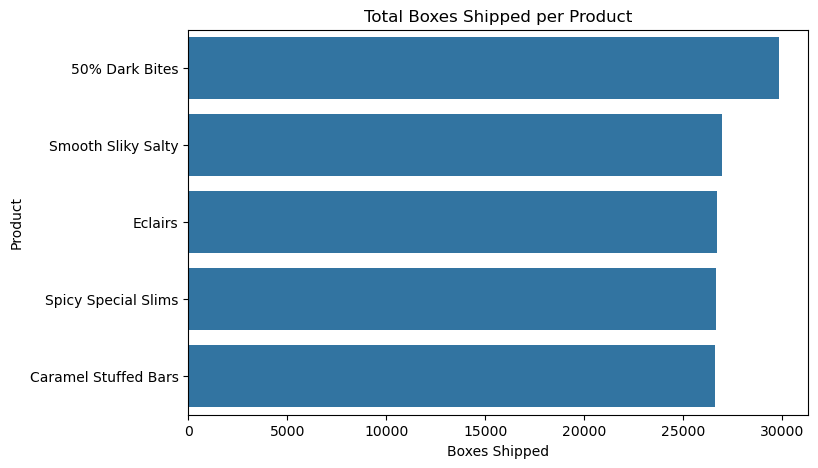

In [46]:
# Barchart showing the Boxes Shipped per product

plt.figure(figsize=(8, 5))
sns.barplot(x=Shipped_Product.values, y=Shipped_Product.index)
plt.title('Total Boxes Shipped per Product')
plt.xlabel('Boxes Shipped')
plt.ylabel('Product')
plt.show()

In [47]:
# checking the Boxes Shipped per Country

Country_boxes = df.groupby('Country')['Boxes Shipped'].sum().sort_values(ascending=False).head()
Country_boxes

Country
Australia    99618
Canada       95158
UK           92523
India        89968
USA          81820
Name: Boxes Shipped, dtype: int64

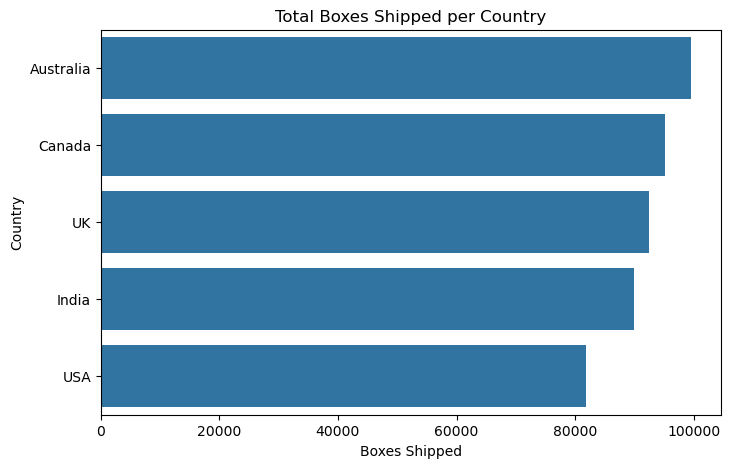

In [48]:
# Barchart showing Boxes Shipped per Country

plt.figure(figsize=(8, 5))
sns.barplot(x=Country_boxes.values, y=Country_boxes.index)
plt.title('Total Boxes Shipped per Country')
plt.xlabel('Boxes Shipped')
plt.ylabel('Country')
plt.show()

In [49]:
# checking the Boxes Shipped per Country Sales Person

Sales_Person_boxes = df.groupby('Sales Person')['Boxes Shipped'].sum().sort_values(ascending=False).head()
Sales_Person_boxes

Sales Person
Karlen McCaffrey       29553
Beverie Moffet         28027
Dennison Crosswaite    26862
Kelci Walkden          26605
Oby Sorrel             26390
Name: Boxes Shipped, dtype: int64

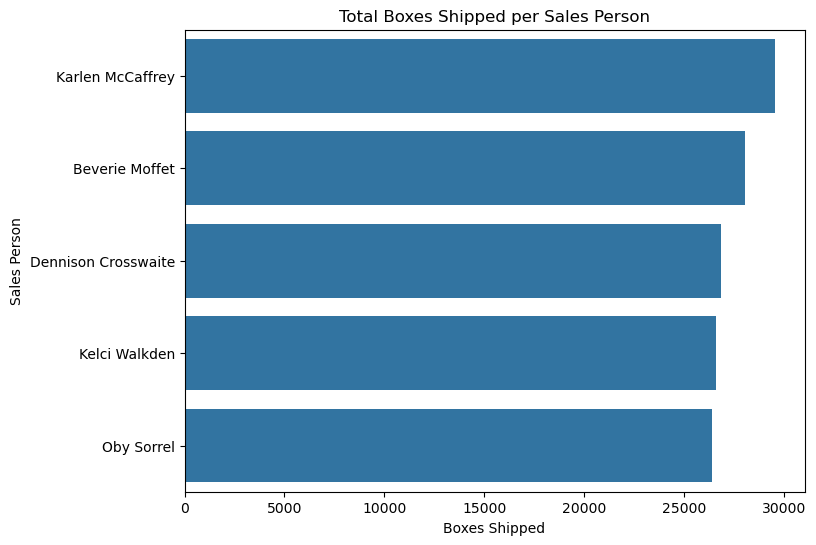

In [50]:
# Barchart showing Boxes Shipped per Sales Person

plt.figure(figsize=(8, 6))
sns.barplot(x=Sales_Person_boxes.values, y=Sales_Person_boxes.index)
plt.title('Total Boxes Shipped per Sales Person')
plt.xlabel('Boxes Shipped')
plt.ylabel('Sales Person')
plt.show()

In [51]:
# Number of orders per country

Country_Count = df['Country'].value_counts()
Country_Count

Country
Australia      615
India          552
USA            537
UK             534
Canada         525
New Zealand    519
Name: count, dtype: int64

In [52]:
# Percentage of orders per country

print (df['Country'].value_counts(normalize = True)* 100)

Country
Australia      18.738574
India          16.819013
USA            16.361974
UK             16.270567
Canada         15.996344
New Zealand    15.813528
Name: proportion, dtype: float64


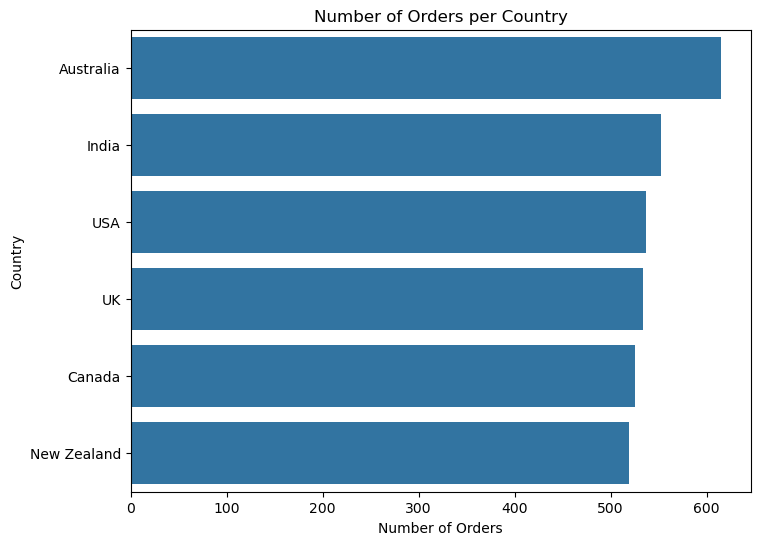

In [53]:
# Checking the Distribution of Orders per Country

plt.figure(figsize=(8, 6))
sns.barplot(x=Country_Count.values, y=Country_Count.index)
plt.title('Number of Orders per Country')
plt.xlabel('Number of Orders')
plt.ylabel('Country')
plt.show()

In [54]:
# checking the average revenue generated per Country

Avg_Order = df.groupby('Country')['Amount'].mean().sort_values(ascending=False).head()
Avg_Order

Country
UK             6302.226404
USA            6171.057896
India          6057.483388
Australia      5929.177805
New Zealand    5864.458651
Name: Amount, dtype: float64

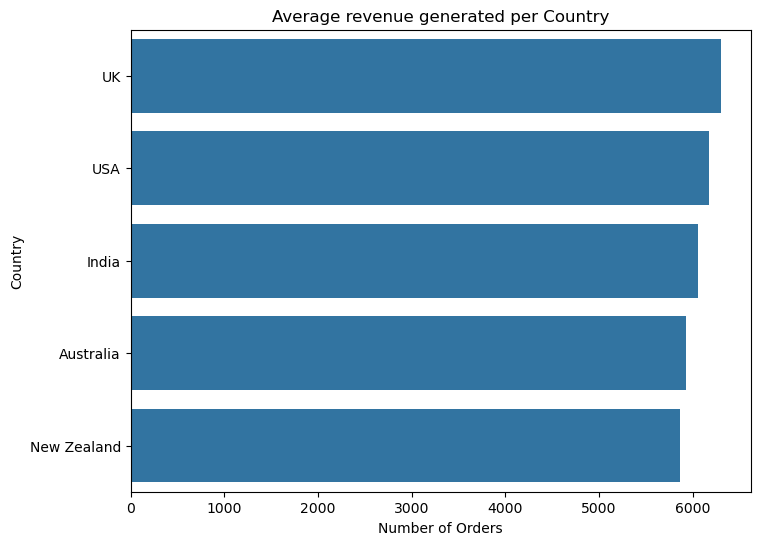

In [55]:
# Barplot showing the Average revenue generated per Country

plt.figure(figsize=(8, 6))
sns.barplot(x=Avg_Order.values, y=Avg_Order.index)
plt.title('Average revenue generated per Country')
plt.xlabel('Number of Orders')
plt.ylabel('Country')
plt.show()

In [56]:
# checking the average order per Country

Avg_Box = df.groupby('Country')['Boxes Shipped'].mean().sort_values(ascending=False).head()
Avg_Box

Country
Canada         181.253333
UK             173.264045
India          162.985507
Australia      161.980488
New Zealand    156.743738
Name: Boxes Shipped, dtype: float64

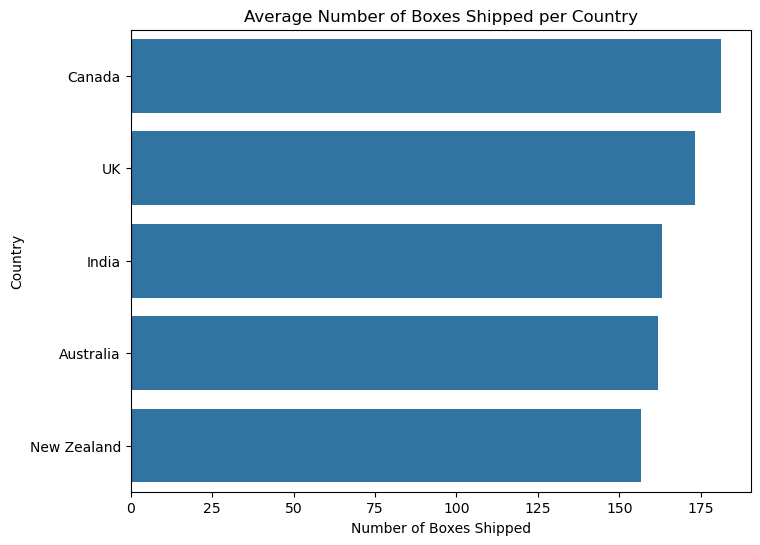

In [57]:
# Checking the Average Distribution of Boxes Shipped per Country

plt.figure(figsize=(8, 6))
sns.barplot(x=Avg_Box.values, y=Avg_Box.index)
plt.title('Average Number of Boxes Shipped per Country')
plt.xlabel('Number of Boxes Shipped')
plt.ylabel('Country')
plt.show()

In [58]:
# Number of orders handled by each sales person

Sales_Person = (df['Sales Person'].value_counts().head(10))
Sales_Person

Sales Person
Kelci Walkden          162
Brien Boise            159
Van Tuxwell            153
Beverie Moffet         150
Dennison Crosswaite    147
Oby Sorrel             147
Ches Bonnell           144
Karlen McCaffrey       141
Gigi Bohling           141
Curtice Advani         138
Name: count, dtype: int64

In [59]:
# Percentage Number of orders handled by each Sales Person

print (df['Sales Person'].value_counts(normalize = True).head()* 100)

Sales Person
Kelci Walkden          4.936015
Brien Boise            4.844607
Van Tuxwell            4.661792
Beverie Moffet         4.570384
Dennison Crosswaite    4.478976
Name: proportion, dtype: float64


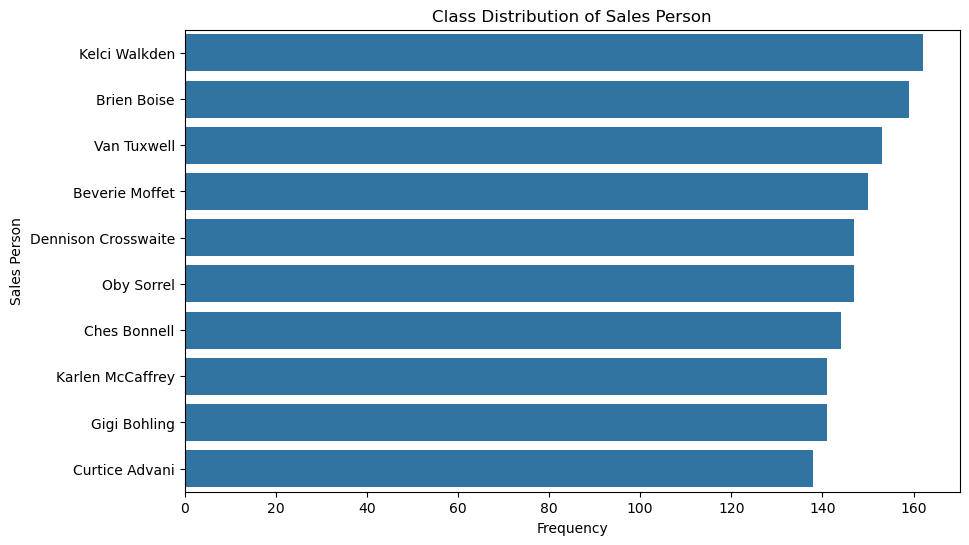

In [60]:
# Barchart showing the Number of orders handled by each Sales Person

plt.figure(figsize=(10, 6))
sns.barplot(x=Sales_Person.values, y=Sales_Person.index)
plt.xlabel('Frequency')
plt.ylabel('Sales Person')
plt.title('Class Distribution of Sales Person')
plt.show()

In [61]:
# Average revenue generated per each sales person

Sales_Person_Amount = df.groupby('Sales Person')['Amount'].mean().sort_values(ascending=False).head()
Sales_Person_Amount

Sales Person
Madelene Upcott        7481.694222
Ches Bonnell           7101.388611
Oby Sorrel             6919.755918
Rafaelita Blaksland    6557.504412
Camilla Castle         6548.053437
Name: Amount, dtype: float64

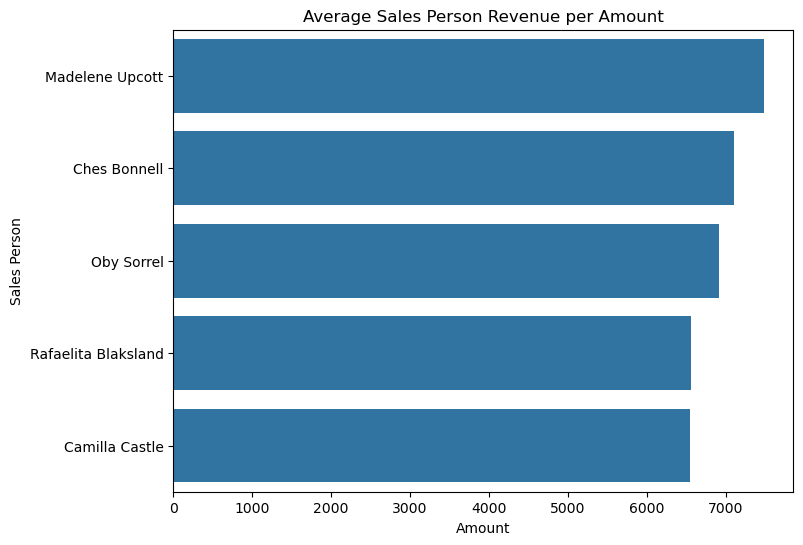

In [62]:
# Barplot showing the Average revenue generated per each sales person

plt.figure(figsize=(8, 6))
sns.barplot(x=Sales_Person_Amount.values, y=Sales_Person_Amount.index)
plt.title('Average Sales Person Revenue per Amount')
plt.xlabel('Amount')
plt.ylabel('Sales Person')
plt.show()

In [63]:
# Average Boxes Shipped per each sales person

Sales_Person_Boxes = df.groupby('Sales Person')['Boxes Shipped'].mean().sort_values(ascending=False).head()
Sales_Person_Boxes

Sales Person
Karlen McCaffrey       209.595745
Jan Morforth           199.658120
Dotty Strutley         193.768519
Beverie Moffet         186.846667
Dennison Crosswaite    182.734694
Name: Boxes Shipped, dtype: float64

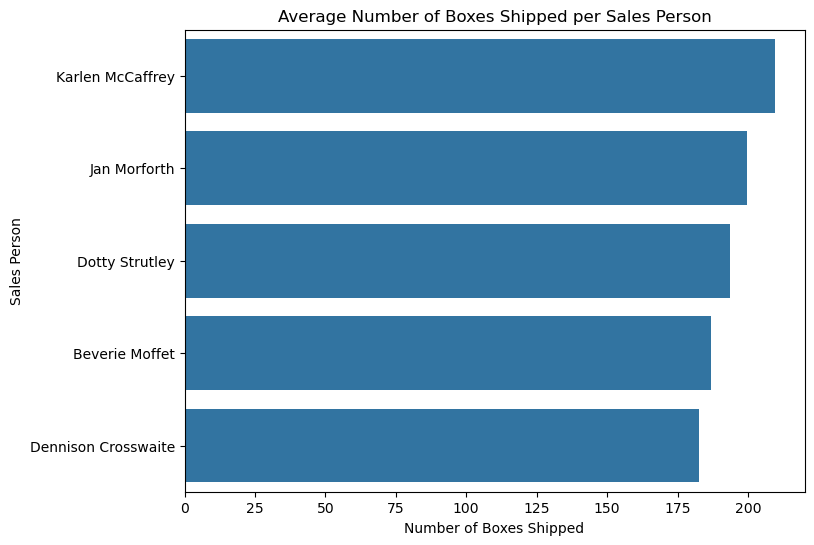

In [64]:
# Barchart showing the Average Distribution of Boxes Shipped per Country

plt.figure(figsize=(8, 6))
sns.barplot(x=Sales_Person_Boxes.values, y=Sales_Person_Boxes.index)
plt.title('Average Number of Boxes Shipped per Sales Person')
plt.xlabel('Number of Boxes Shipped')
plt.ylabel('Sales Person')
plt.show()

In [65]:
# Number of orders placed for each Product

Product_Count = (df['Product'].value_counts().head(10))
Product_Count

Product
50% Dark Bites         180
Eclairs                180
Smooth Sliky Salty     177
White Choc             174
Drinking Coco          168
Spicy Special Slims    162
Organic Choco Syrup    156
After Nines            150
85% Dark Bars          150
Fruit & Nut Bars       150
Name: count, dtype: int64

In [66]:
# Percentage Number of orders placed for each Product

print (df['Product'].value_counts(normalize = True).head()* 100)

Product
50% Dark Bites        5.484461
Eclairs               5.484461
Smooth Sliky Salty    5.393053
White Choc            5.301645
Drinking Coco         5.118830
Name: proportion, dtype: float64


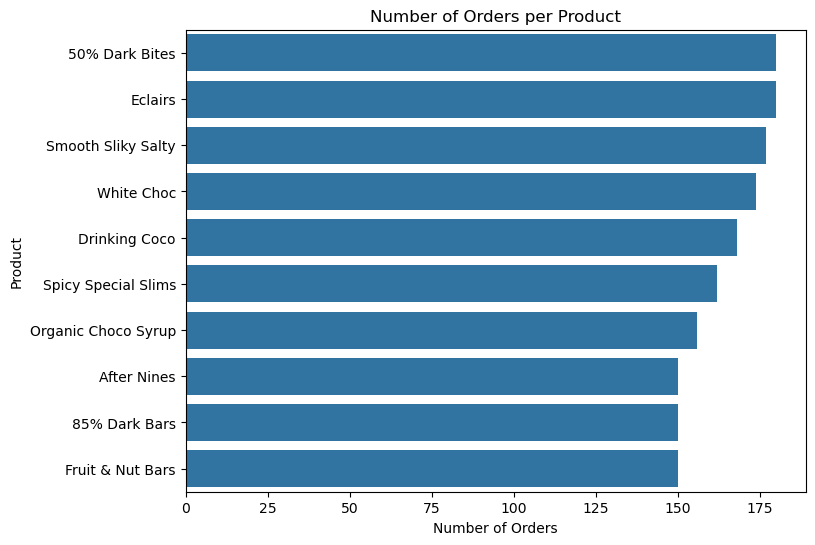

In [67]:
# Barchart showing the Distribution of Orders per Product

plt.figure(figsize=(8, 6))
sns.barplot(x=Product_Count.values, y=Product_Count.index)
plt.title('Number of Orders per Product')
plt.xlabel('Number of Orders')
plt.ylabel('Product')
plt.show()

In [68]:
# Average revenue generated per Product

Product_Amount = df.groupby('Product')['Amount'].mean().sort_values(ascending=False).head()
Product_Amount

Product
Peanut Butter Cubes     7051.640068
Mint Chip Choco         6703.626296
Choco Coated Almonds    6607.375299
Manuka Honey Choco      6557.096519
99% Dark & Pure         6530.839796
Name: Amount, dtype: float64

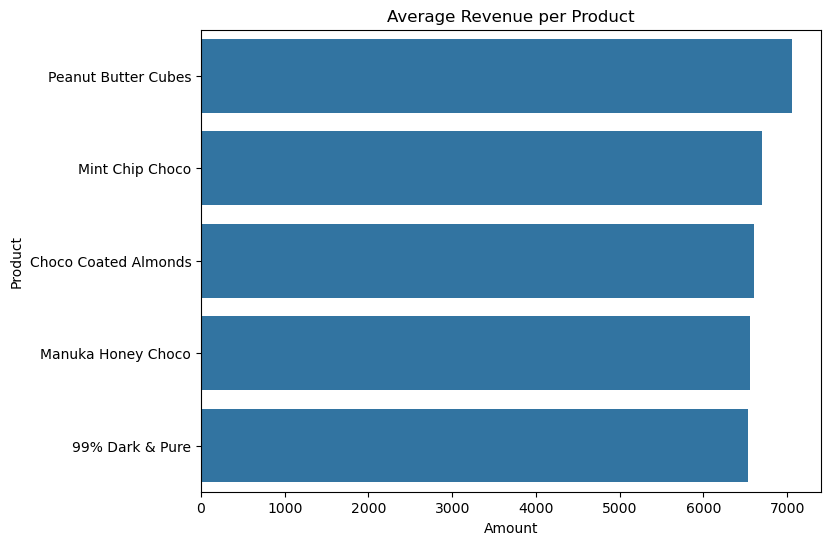

In [69]:
# Barplot showing the Average revenue generated per Product

plt.figure(figsize=(8, 6))
sns.barplot(x=Product_Amount.values, y=Product_Amount.index)
plt.title('Average Revenue per Product')
plt.xlabel('Amount')
plt.ylabel('Product')
plt.show()

In [70]:
# Average Boxes Shipped per each sales person

Product_Boxes = df.groupby('Product')['Boxes Shipped'].mean().sort_values(ascending=False).head()
Product_Boxes

Product
Caramel Stuffed Bars    206.015504
70% Dark Bites          194.634921
Mint Chip Choco         186.288889
Manuka Honey Choco      175.822222
Baker's Choco Chips     174.373984
Name: Boxes Shipped, dtype: float64

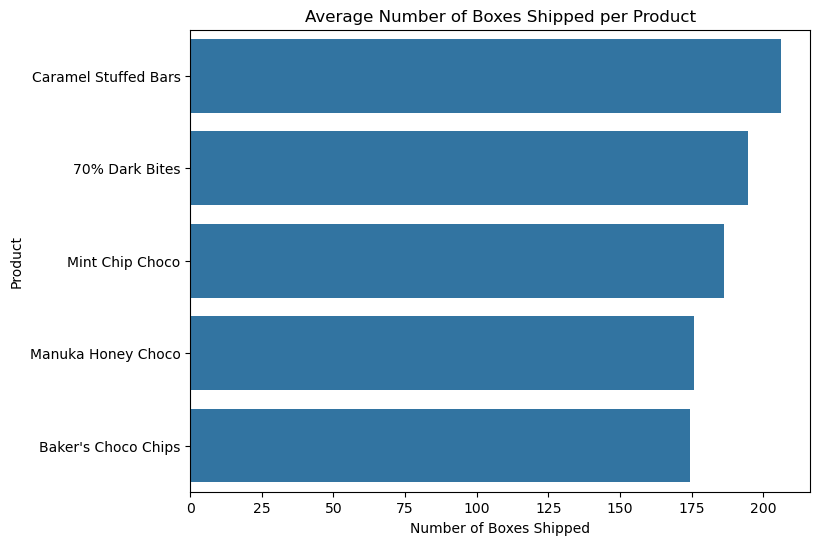

In [71]:
# Barchart showing the Average Distribution of Boxes Shipped per Product

plt.figure(figsize=(8, 6))
sns.barplot(x=Product_Boxes.values, y=Product_Boxes.index)
plt.title('Average Number of Boxes Shipped per Product')
plt.xlabel('Number of Boxes Shipped')
plt.ylabel('Product')
plt.show()

In [72]:
numeric_df = df.select_dtypes(include=['number'])
numeric_df.cov()

,Amount,Boxes Shipped
Amount,1.930706e+07,-7168.361435
Boxes Shipped,-7.168361e+03,15382.135020


In [73]:
# Correlation matrix — examining relationship between Amount and Boxes Shipped

correlation_matrix = numeric_df.corr()
correlation_matrix

,Amount,Boxes Shipped
Amount,1.000000,-0.013154
Boxes Shipped,-0.013154,1.000000


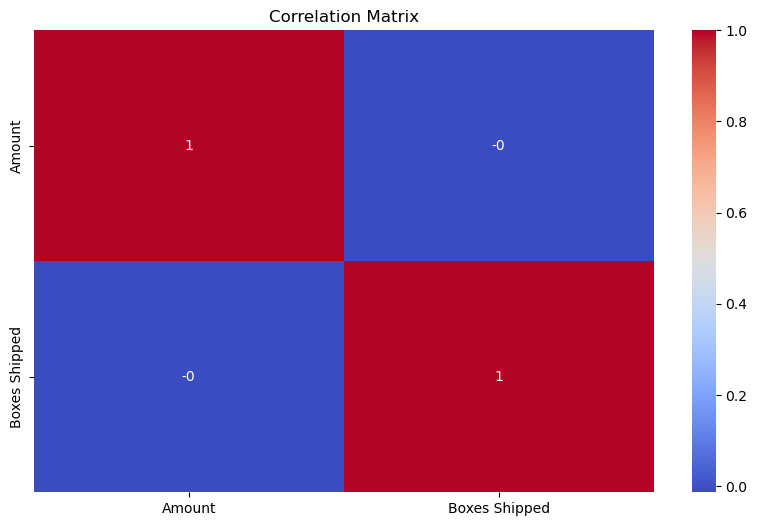

In [74]:
# Heatmap to visualize correlation between Amount and Boxes Shipped -show near zero correlation

plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, fmt='.0f', cmap="coolwarm")
plt.title('Correlation Matrix')
plt.show()

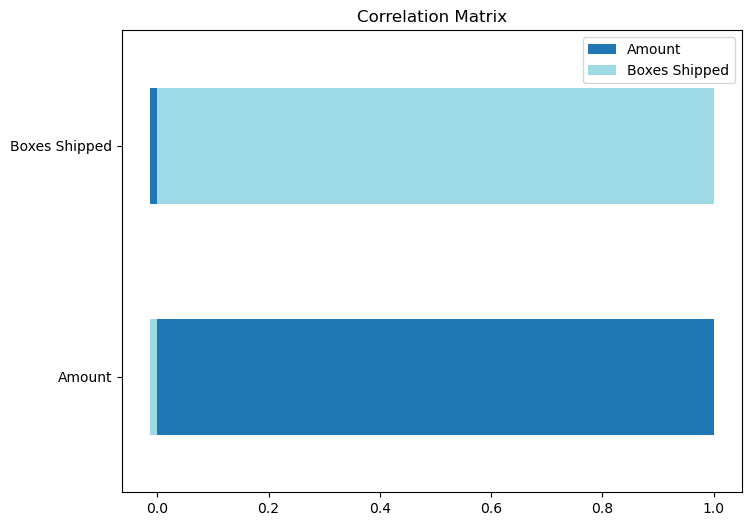

In [75]:
# Barchart visualizing correlation between Amount and Boxes Shipped -show near zero correlation

correlation_matrix.plot(kind='barh', stacked=True, figsize=(8, 6), colormap='tab20')
plt.title('Correlation Matrix')
plt.show()

In [76]:
# Total amount by product and country
Product_Country_Amount = df.groupby(['Product', 'Country'])['Amount'].sum().unstack().head()
Product_Country_Amount 

Country,Australia,Canada,India,New Zealand,UK,USA
Product,,,,,,
50% Dark Bites,280066.82,141804.27,206943.76,114195.94,160112.12,184536.44
70% Dark Bites,127540.46,189698.51,110588.32,116637.66,66751.89,66129.38
85% Dark Bars,123398.33,120293.78,179605.94,215881.58,132181.76,183906.85
99% Dark & Pure,176247.62,140413.72,135933.68,104141.19,251626.82,151670.42
After Nines,89658.71,134870.95,187638.02,177409.93,109266.08,138371.98


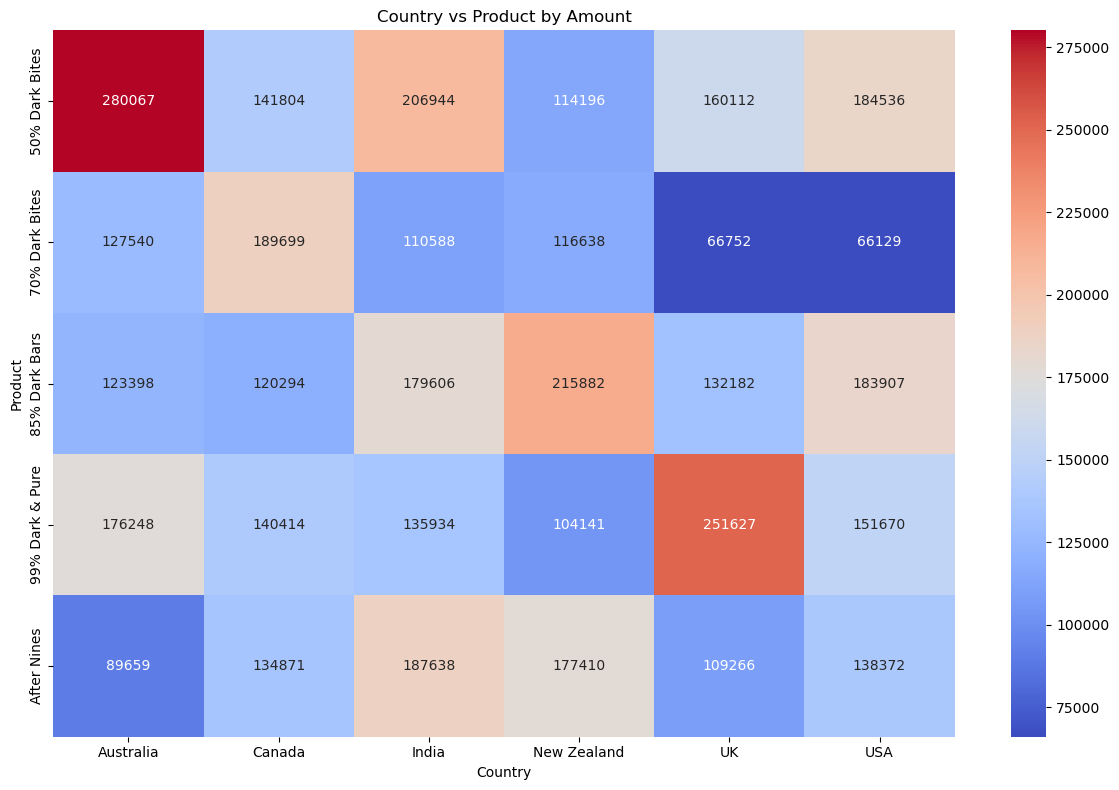

In [77]:
# Heatmap showing Total revenue by product and country

plt.figure(figsize=(12, 8))
sns.heatmap(Product_Country_Amount, annot=True, fmt='.0f', cmap='coolwarm')
plt.title('Country vs Product by Amount')
plt.tight_layout()
plt.show()

In [78]:
# The Total boxes shipped by product and country

Product_Country_Shipped = df.groupby(['Product', 'Country'])['Boxes Shipped'].sum().unstack().head()
Product_Country_Shipped

Country,Australia,Canada,India,New Zealand,UK,USA
Product,,,,,,
50% Dark Bites,9692,2061,3751,2878,5966,5462
70% Dark Bites,6389,4813,4660,2864,3887,1911
85% Dark Bars,3649,2920,4799,5376,2141,4943
99% Dark & Pure,4116,4386,4420,2200,4292,5404
After Nines,2731,4120,5751,4021,3019,5514


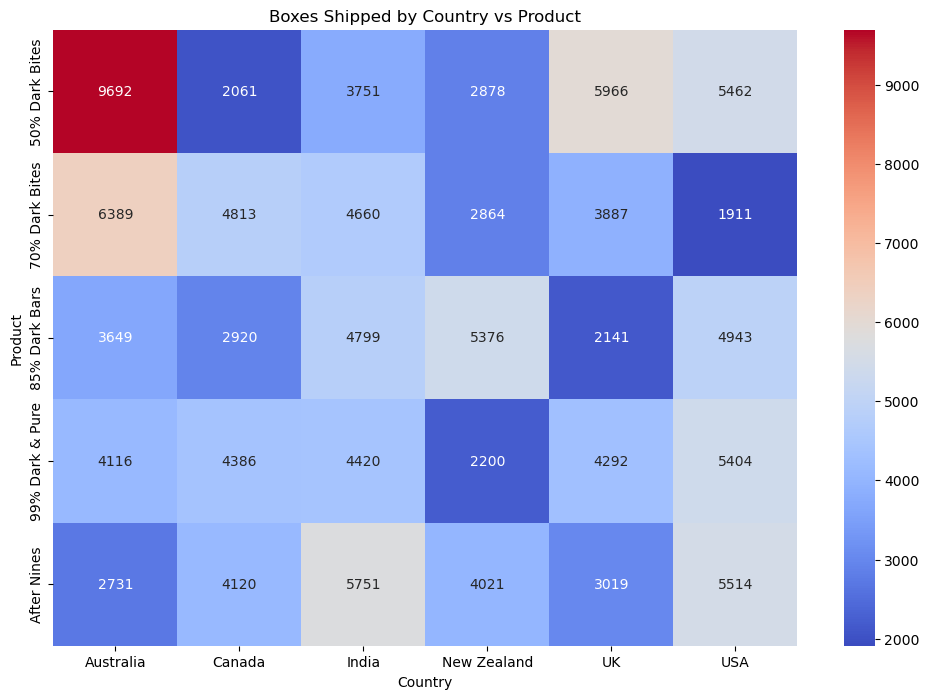

In [79]:
# Heatmap showing Total boxes shipped by product and country

plt.figure(figsize=(12, 8))
sns.heatmap(Product_Country_Shipped, annot=True, fmt='.0f', cmap='coolwarm')
plt.title('Boxes Shipped by Country vs Product')
plt.show()

In [80]:
# Total revenue by sales person and country
Sales_Country_Amount = df.groupby(['Sales Person', 'Country'])['Amount'].sum().unstack().head()
Sales_Country_Amount

Country,Australia,Canada,India,New Zealand,UK,USA
Sales Person,,,,,,
Andria Kimpton,98362.44,125723.90,85859.16,106369.83,119197.28,112702.20
Barr Faughny,148599.65,145249.46,100435.33,198149.28,49310.80,189082.39
Beverie Moffet,87891.54,231510.29,132064.14,144926.36,125577.48,170451.56
Brien Boise,193359.38,190561.00,194341.81,133659.43,100216.41,185188.45
Camilla Castle,101819.83,95660.41,99487.83,129269.81,63159.15,139216.10


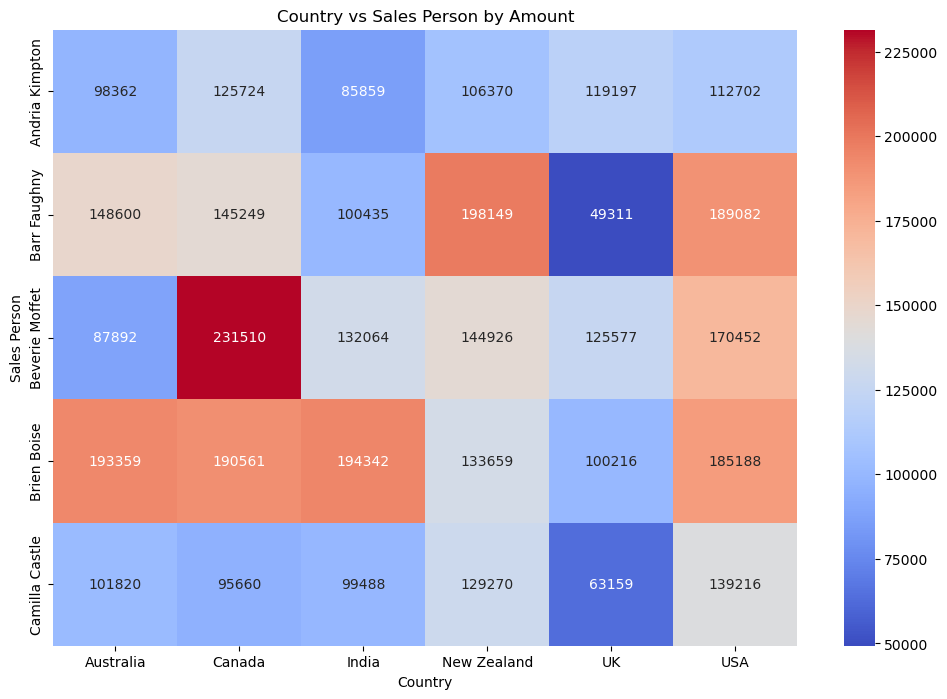

In [81]:
# Heatmap showing the Total revenue by sales person and country

plt.figure(figsize=(12, 8))
sns.heatmap(Sales_Country_Amount, annot=True, fmt='.0f', cmap='coolwarm')
plt.title('Country vs Sales Person by Amount')
plt.show()

In [82]:
# Total Boxes Shipped by sales person and country
Sales_Country_Boxes = df.groupby(['Sales Person', 'Country'])['Boxes Shipped'].sum().unstack().head()
Sales_Country_Boxes

Country,Australia,Canada,India,New Zealand,UK,USA
Sales Person,,,,,,
Andria Kimpton,4022,5057,2625,2983,3475,1568
Barr Faughny,2035,3859,2937,5129,2910,2650
Beverie Moffet,6753,4016,5122,3521,3467,5148
Brien Boise,4397,5464,4644,4446,2317,3470
Camilla Castle,3314,1428,3393,2665,1893,3812


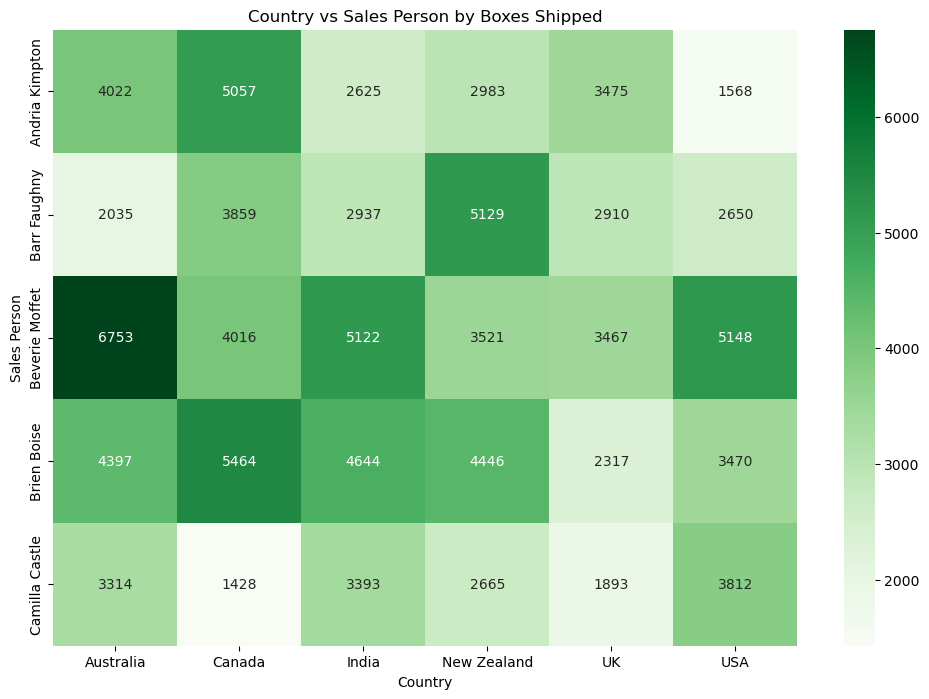

In [83]:
#  Heatmap showing the Total Boxes Shipped by sales person and country

plt.figure(figsize=(12, 8))
sns.heatmap(Sales_Country_Boxes, annot=True, fmt='.0f', cmap='Greens')
plt.title('Country vs Sales Person by Boxes Shipped')
plt.show()

In [84]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [85]:
df.index

DatetimeIndex(['2022-01-04', '2022-08-01', '2022-07-07', '2022-04-27',
               '2022-02-24', '2022-06-06', '2022-01-25', '2022-03-24',
               '2022-04-20', '2022-07-04',
               ...
               '2024-03-14', '2024-05-24', '2024-01-28', '2024-05-24',
               '2024-08-19', '2024-05-17', '2024-06-07', '2024-07-26',
               '2024-07-28', '2024-05-23'],
              dtype='datetime64[ns]', name='Date', length=3282, freq=None)

In [86]:
# Convert index to datetime
df.index = pd.to_datetime(df.index)

In [87]:
monthly_sales = df['Amount'].resample('M').sum()
monthly_sales

Date
2022-01-31     896105.00
2022-02-28     699377.00
2022-03-31     749483.00
2022-04-30     674051.00
2022-05-31     752892.00
2022-06-30     865144.00
2022-07-31     803425.00
2022-08-31     743148.00
2022-09-30          0.00
2022-10-31          0.00
2022-11-30          0.00
2022-12-31          0.00
2023-01-31     958985.77
2023-02-28     749617.46
2023-03-31     807494.33
2023-04-30     727743.72
2023-05-31     811951.78
2023-06-30     932625.17
2023-07-31     861856.66
2023-08-31     793103.07
2023-09-30          0.00
2023-10-31          0.00
2023-11-30          0.00
2023-12-31          0.00
2024-01-31    1013621.82
2024-02-29     783102.44
2024-03-31     847791.96
2024-04-30     760132.50
2024-05-31     850906.79
2024-06-30     976162.77
2024-07-31     902250.63
2024-08-31     830599.99
Freq: ME, Name: Amount, dtype: float64

In [88]:
 # returning NA instead of 0 for empty months
monthly_sales = (df.resample('M')['Amount']
                 .sum(min_count=1)      
                 .astype(float)
                 .interpolate(method='time'))
monthly_sales

Date
2022-01-31    8.961050e+05
2022-02-28    6.993770e+05
2022-03-31    7.494830e+05
2022-04-30    6.740510e+05
2022-05-31    7.528920e+05
2022-06-30    8.651440e+05
2022-07-31    8.034250e+05
2022-08-31    7.431480e+05
2022-09-30    7.854691e+05
2022-10-31    8.292010e+05
2022-11-30    8.715221e+05
2022-12-31    9.152539e+05
2023-01-31    9.589858e+05
2023-02-28    7.496175e+05
2023-03-31    8.074943e+05
2023-04-30    7.277437e+05
2023-05-31    8.119518e+05
2023-06-30    9.326252e+05
2023-07-31    8.618567e+05
2023-08-31    7.931031e+05
2023-09-30    8.363420e+05
2023-10-31    8.810223e+05
2023-11-30    9.242613e+05
2023-12-31    9.689416e+05
2024-01-31    1.013622e+06
2024-02-29    7.831024e+05
2024-03-31    8.477920e+05
2024-04-30    7.601325e+05
2024-05-31    8.509068e+05
2024-06-30    9.761628e+05
2024-07-31    9.022506e+05
2024-08-31    8.306000e+05
Freq: ME, Name: Amount, dtype: float64

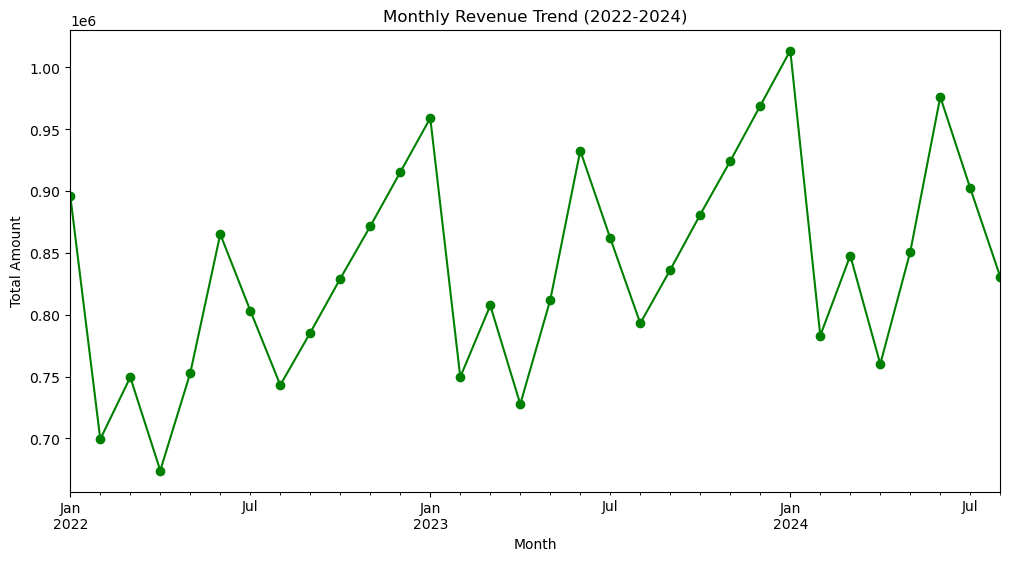

In [89]:
# Visualise monthly revenue trend 
plt.figure(figsize=(12, 6))
monthly_sales.plot(color='green', marker='o')
plt.title('Monthly Revenue Trend (2022-2024)')
plt.xlabel('Month')
plt.ylabel('Total Amount')
plt.show()

In [90]:
# Extract year for comparison
df['Year'] = df.index.year
df['Month'] = df.index.month

In [91]:
# Pivot for year comparison
yearly_monthly = df.groupby(['Year', 'Month'])['Amount'].sum().unstack(0)
yearly_monthly

Year,2022,2023,2024
Month,,,
1,896105.0,958985.77,1013621.82
2,699377.0,749617.46,783102.44
3,749483.0,807494.33,847791.96
4,674051.0,727743.72,760132.50
5,752892.0,811951.78,850906.79
6,865144.0,932625.17,976162.77
7,803425.0,861856.66,902250.63
8,743148.0,793103.07,830599.99


<Figure size 1400x600 with 0 Axes>

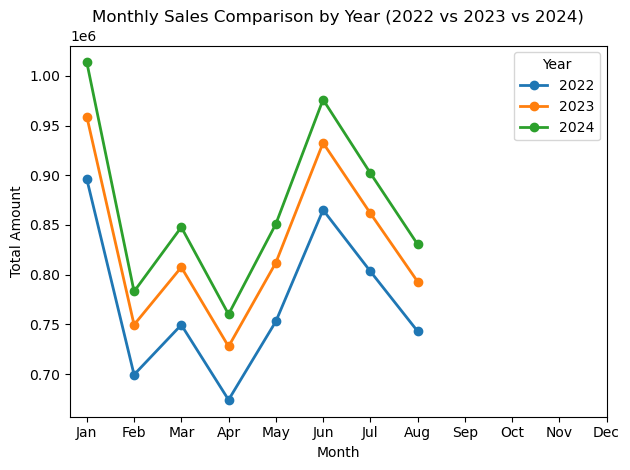

In [92]:
# Compare monthly sales patterns across years to spot seasonality and year-on-year growth

plt.figure(figsize=(14, 6))
yearly_monthly.plot(marker='o', linewidth=2)
plt.title('Monthly Sales Comparison by Year (2022 vs 2023 vs 2024)')
plt.xlabel('Month')
plt.ylabel('Total Amount')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                           'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.legend(title='Year')
plt.tight_layout()
plt.show()

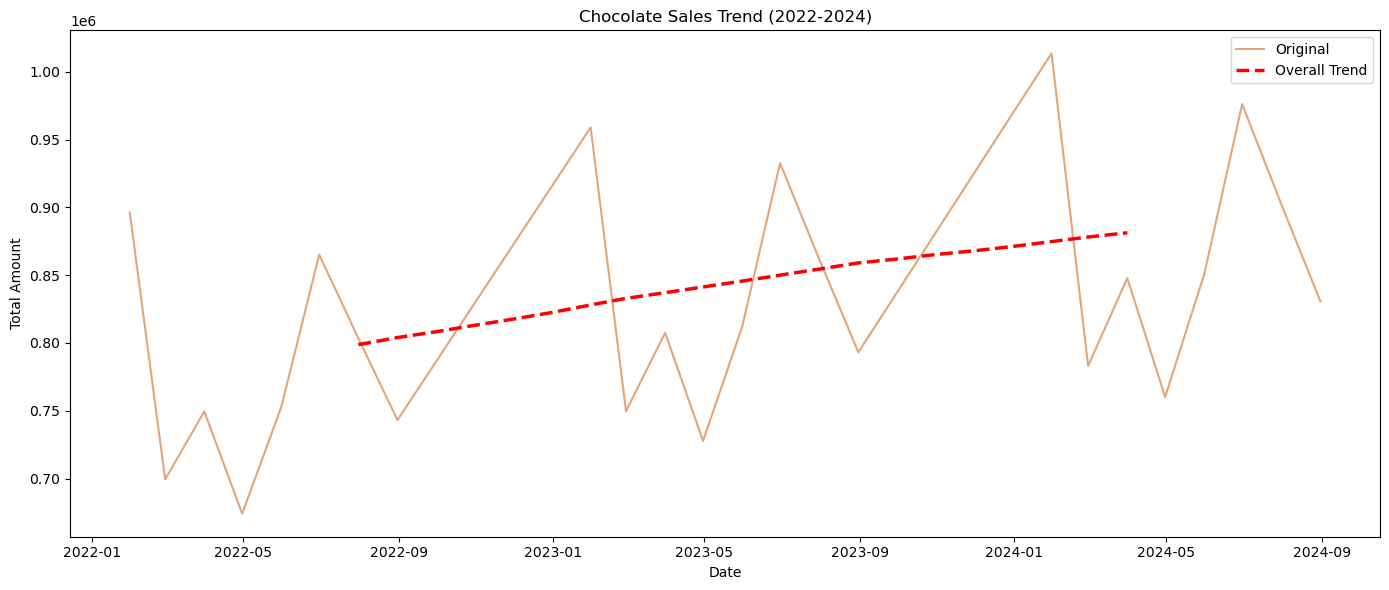

In [93]:
# Calculate 12-month rolling average to reveal overall trend
trend = monthly_sales.rolling(window=12, center=True).mean()

plt.figure(figsize=(14, 6))

# Original
plt.plot(monthly_sales.index, monthly_sales.values,
         color='chocolate', linewidth=1.5, 
         alpha=0.6, label='Original')

# Trend
plt.plot(trend.index, trend.values,
         color='red', linewidth=2.5, 
        linestyle='--', label='Overall Trend')

plt.title('Chocolate Sales Trend (2022-2024)')
plt.xlabel('Date')
plt.ylabel('Total Amount')
plt.legend()
plt.tight_layout()
plt.show()

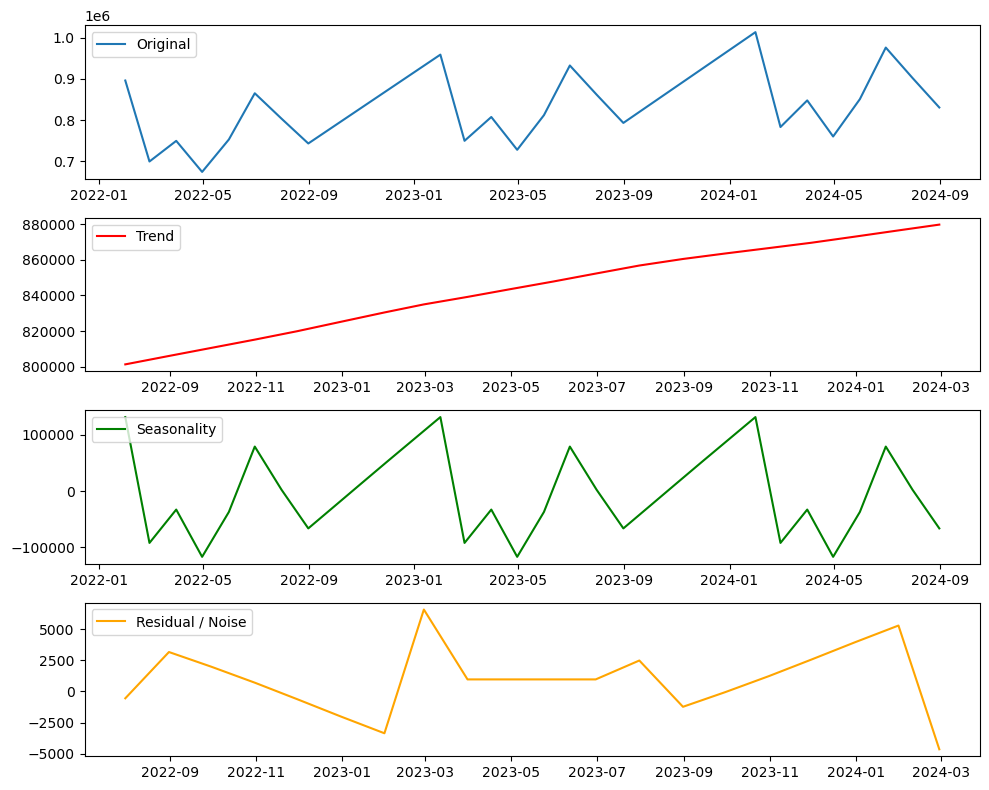

<Figure size 640x480 with 0 Axes>

In [94]:
# Decompose monthly sales into its core components: trend, seasonality, and residual noise

decomposition = seasonal_decompose(monthly_sales, model='additive', period=12)

trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid


plt.figure(figsize=(10,8))

plt.subplot(4,1,1)
plt.plot(monthly_sales, label='Original')
plt.legend(loc='upper left')

plt.subplot(4,1,2)
plt.plot(trend, label='Trend', color='red')
plt.legend(loc='upper left')

plt.subplot(4,1,3)
plt.plot(seasonal, label='Seasonality', color='green')
plt.legend(loc='upper left')

plt.subplot(4,1,4)
plt.plot(residual, label='Residual / Noise', color='orange')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

plt.suptitle('Chocolate Sales Decomposition (2022-2024)', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

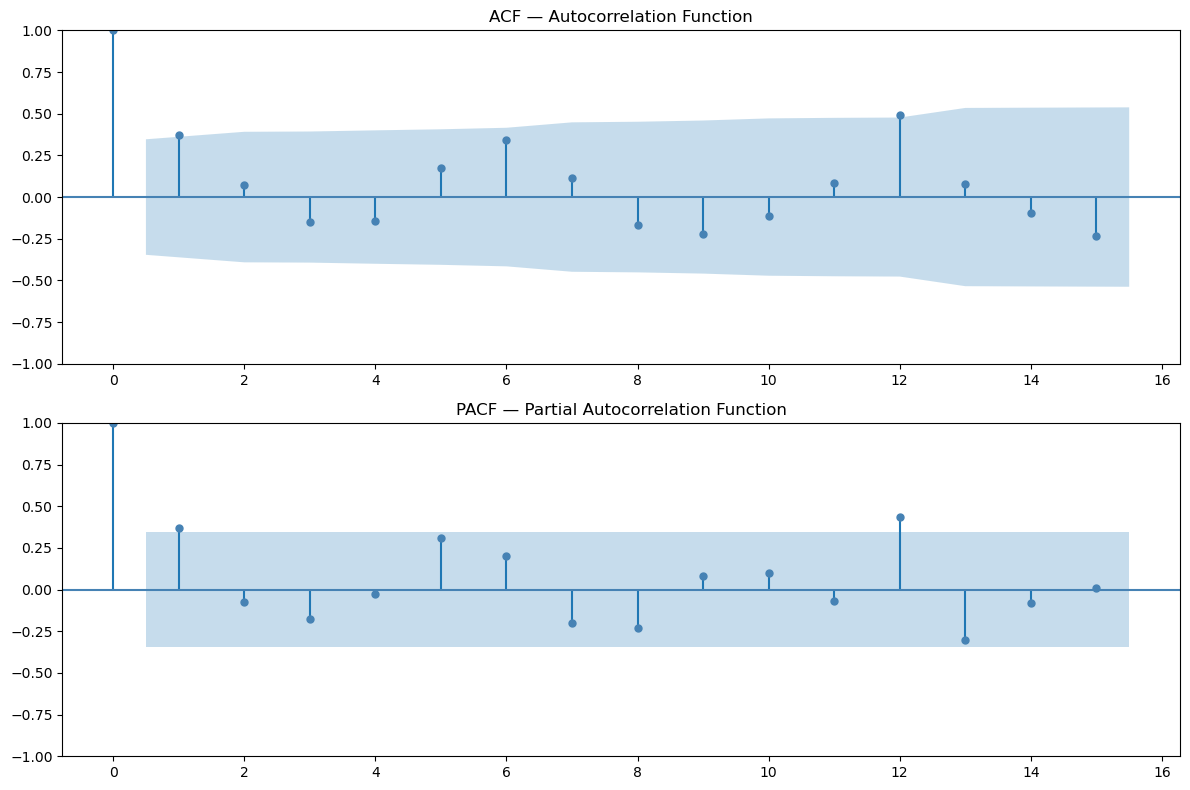

In [95]:
# Plot ACF & PACF
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

plot_acf(monthly_sales, lags=min(30, len(monthly_sales)//2 - 1), 
         ax=axes[0], 
         title='ACF — Autocorrelation Function',
         color='steelblue')

plot_pacf(monthly_sales, lags=min(30, len(monthly_sales)//2 - 1), 
          ax=axes[1], 
          title='PACF — Partial Autocorrelation Function',
          color='steelblue',
          method='ywm')  # 'ywm' is more stable than default for small samples

plt.tight_layout()
plt.show()

In [96]:
# Run the Augmented Dickey-Fuller (ADF) test to check if the series is stationary

result = adfuller(monthly_sales)

print('ADF Statistic:', result[0])
print('p-value:', result[1])
if result[1] < 0.05:
    print("The series is likely stationary")
else:
    print("The series is likely non-stationary")

ADF Statistic: -3.6761496741642046
p-value: 0.004461415622588194
The series is likely stationary


In [97]:
print(result)

(-3.6761496741642046, 0.004461415622588194, 0, 31, {'1%': -3.661428725118324, '5%': -2.960525341210433, '10%': -2.6193188033298647}, 535.8642121885762)


In [98]:
# Split the series into training and test sets (80% train, 20% test)
train_size = int(len(monthly_sales) * 0.8)

train = monthly_sales[:train_size]
test = monthly_sales[train_size:]

In [99]:
train.tail()

Date
2023-09-30    8.363420e+05
2023-10-31    8.810223e+05
2023-11-30    9.242613e+05
2023-12-31    9.689416e+05
2024-01-31    1.013622e+06
Freq: ME, Name: Amount, dtype: float64

In [100]:
test.head()

Date
2024-02-29    783102.44
2024-03-31    847791.96
2024-04-30    760132.50
2024-05-31    850906.79
2024-06-30    976162.77
Freq: ME, Name: Amount, dtype: float64

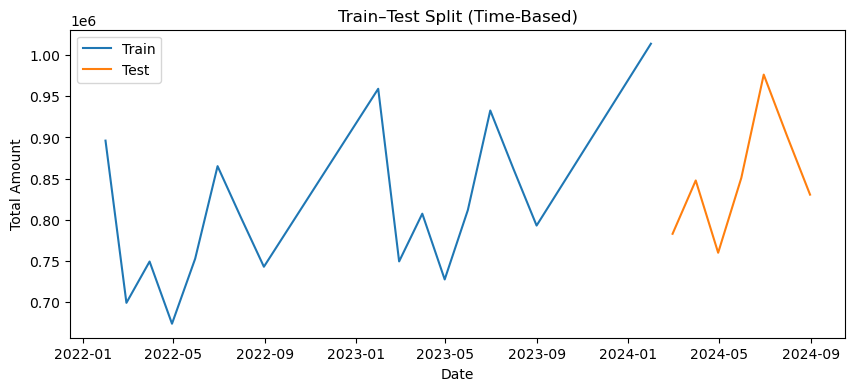

In [101]:
# Line plot showing the training and test sets 
plt.figure(figsize=(10,4))
plt.plot(train, label='Train')
plt.plot(test, label='Test')
plt.legend()
plt.title("Train–Test Split (Time-Based)")
plt.xlabel('Date')
plt.ylabel('Total Amount')
plt.show()

In [102]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.arima.model import ARIMA

In [103]:
# Build and fit the SARIMA model on the training data
model = SARIMAX(train,
    order=(1, 0, 2),
    seasonal_order=(1, 0, 0, 12))

results = model.fit()

In [104]:
# Generate forecast for the same number of steps as the test set
forecast_1 = results.forecast(steps=len(test))

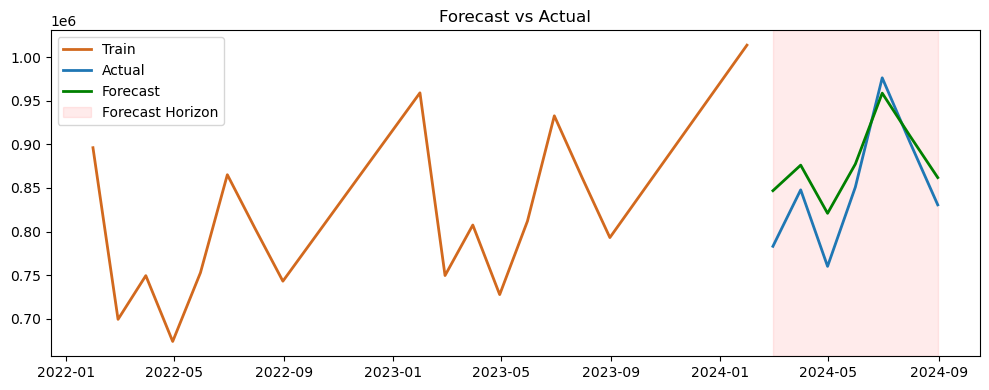

In [105]:
# Plot training data, actual test values, and SARIMA forecast side by side for visual evaluation

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(train, label='Train', color='chocolate', linewidth=2)
ax.plot(test, label='Actual', linewidth=2)
ax.plot(forecast_1, label='Forecast', color='green',
        linewidth=2, linestyle='-')

ax.axvspan(test.index[0], test.index[-1],
           alpha=0.08, color='red',
           label='Forecast Horizon')

ax.legend()
ax.set_title("Forecast vs Actual")
plt.tight_layout()
plt.show()

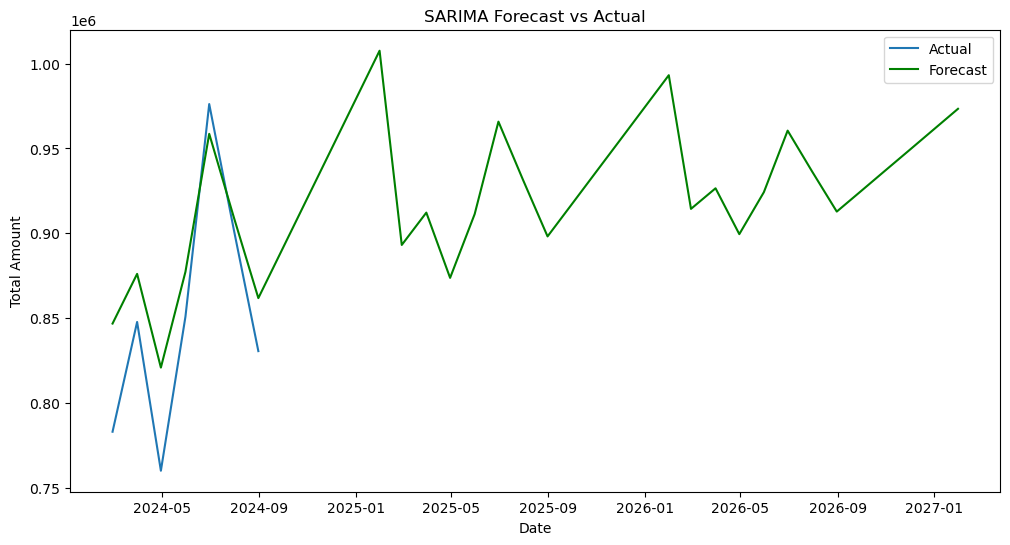

In [106]:
# Generate a 36-step (3-year) forecast with confidence intervals using the fitted SARIMA model

forecast = results.get_forecast(steps=36)

plt.figure(figsize=(12, 6))
plt.plot(test, label='Actual')
plt.plot(forecast.predicted_mean, label='Forecast', color='green')
plt.legend()
plt.title('SARIMA Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Total Amount')
plt.show()

In [107]:
# Forecast on test period
predictions = results.forecast(steps=len(test))
predictions.index = test.index

# MAE
mae = mean_absolute_error(test, predictions)

# RMSE
rmse = np.sqrt(mean_squared_error(test, predictions))

# MAPE
mape = (abs((test - predictions) / test).mean()) * 100

print('Model Evaluation Metrics:')
print('─' * 30)
print(f'MAE:  {mae:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'MAPE: {mape:.2f}%')

Model Evaluation Metrics:
──────────────────────────────
MAE:  33618.35
RMSE: 38899.88
MAPE: 4.14%


In [108]:
# Extract residuals from the fitted SARIMA model
residual

Date
2022-01-31            NaN
2022-02-28            NaN
2022-03-31            NaN
2022-04-30            NaN
2022-05-31            NaN
2022-06-30            NaN
2022-07-31    -552.648130
2022-08-31    3164.809370
2022-09-30    1987.781846
2022-10-31     700.697418
2022-11-30    -620.903649
2022-12-31   -2012.794327
2023-01-31   -3361.620838
2023-02-28    6578.584162
2023-03-31     965.196424
2023-04-30     965.196424
2023-05-31     965.196424
2023-06-30     965.196424
2023-07-31    2483.040977
2023-08-31   -1234.416523
2023-09-30     -57.388999
2023-10-31    1229.695430
2023-11-30    2551.296496
2023-12-31    3943.187174
2024-01-31    5292.013685
2024-02-29   -4648.191315
2024-03-31            NaN
2024-04-30            NaN
2024-05-31            NaN
2024-06-30            NaN
2024-07-31            NaN
2024-08-31            NaN
Freq: ME, Name: resid, dtype: float64

In [109]:
# Extract residuals from the fitted SARIMA model and drop NaN values
residuals = results.resid.dropna()
residuals

Date
2022-01-31    896105.000000
2022-02-28   -189734.872666
2022-03-31      4273.976729
2022-04-30   -113325.492549
2022-05-31     36727.542105
2022-06-30     99723.717141
2022-07-31    -10212.317382
2022-08-31    -38694.278031
2022-09-30     23209.005212
2022-10-31     44093.709693
2022-11-30     68141.518294
2022-12-31     55611.422392
2023-01-31     54458.094967
2023-02-28    -48938.730012
2023-03-31     15821.211912
2023-04-30    -33223.485427
2023-05-31     21385.462607
2023-06-30     45655.117053
2023-07-31     -2690.315844
2023-08-31    -16157.984671
2023-09-30      7493.699725
2023-10-31     14773.998963
2023-11-30     23695.672578
2023-12-31     30024.125097
2024-01-31     35173.882509
Freq: ME, dtype: float64

In [110]:
import scipy.stats as stats
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf

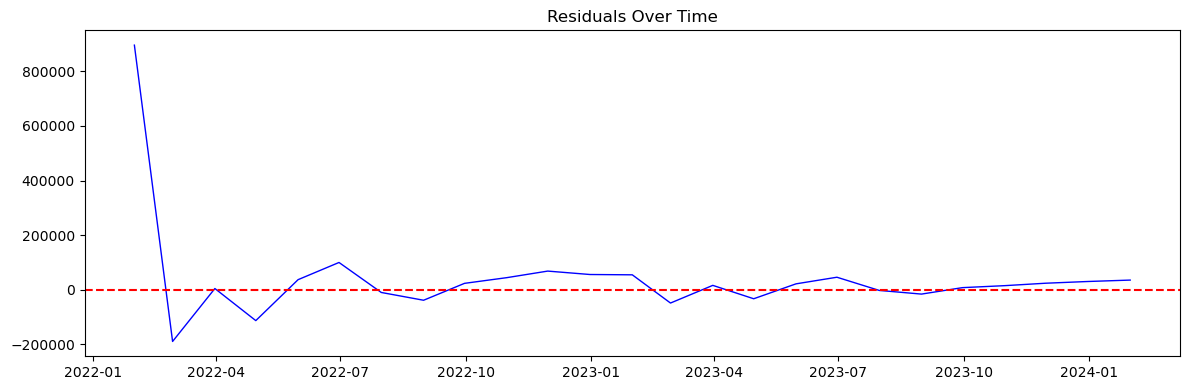

In [111]:
# Plot residuals over time to visually check for randomness and constant variance
plt.figure(figsize=(12, 4))
plt.plot(residuals, color='blue', linewidth=1)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residuals Over Time')
plt.tight_layout()
plt.show()

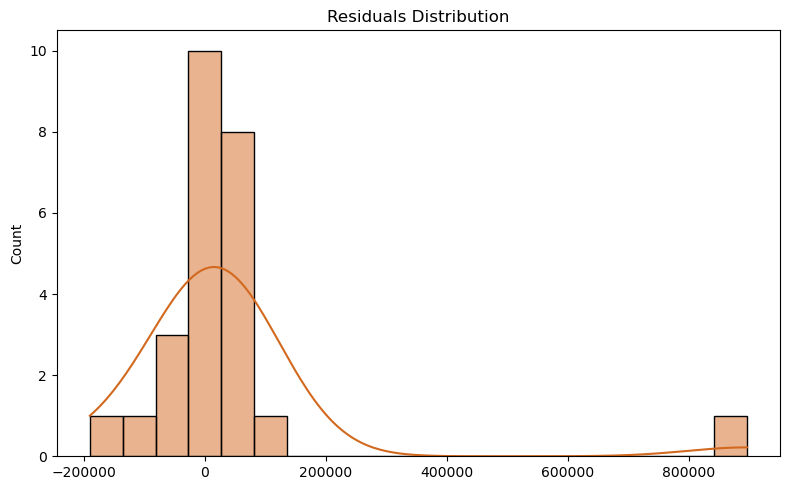

In [112]:
# Plot the distribution of residuals
plt.figure(figsize=(8, 5))
sns.histplot(residuals, bins=20, kde=True, color='chocolate')
plt.title('Residuals Distribution')
plt.tight_layout()
plt.show()

<Figure size 1000x400 with 0 Axes>

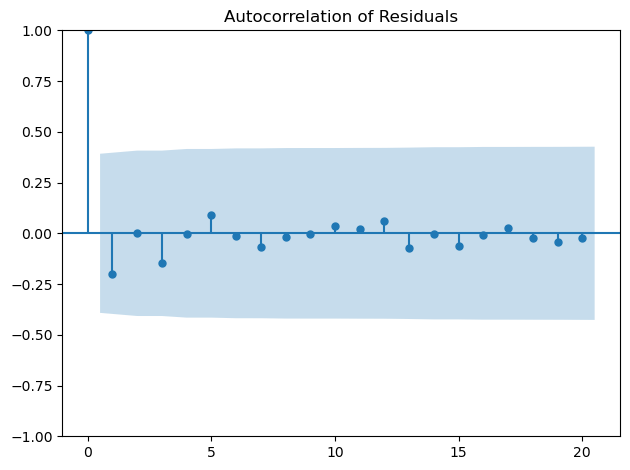

In [113]:
# Plotting ACF for residuals
plt.figure(figsize=(10, 4))
plot_acf(residuals, lags=20)
plt.title('Autocorrelation of Residuals')
plt.tight_layout()
plt.show()

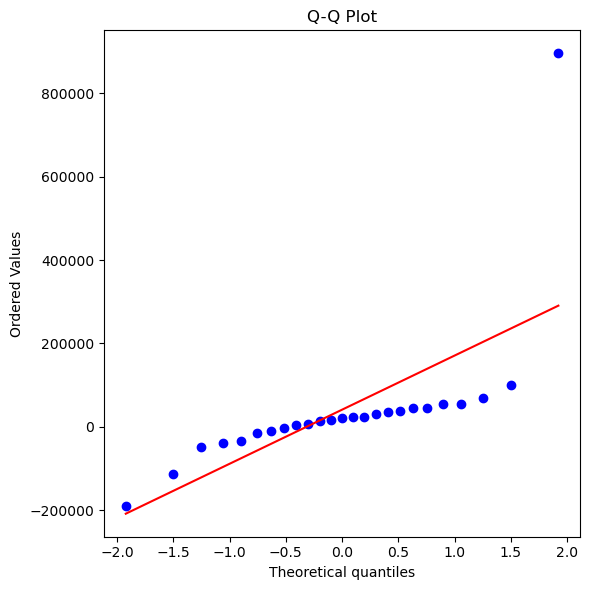

In [114]:
# Plotting Q-Q Plot
plt.figure(figsize=(6, 6))
stats.probplot(residuals, dist='norm', plot=plt)
plt.title('Q-Q Plot')
plt.tight_layout()
plt.show()

In [115]:
# Run the Ljung-Box test to statistically check if residuals are white noise (no autocorrelation)
lb_test = acorr_ljungbox(residuals, lags=[10], return_df=True)
print(lb_test)

     lb_stat  lb_pvalue
10  2.299991   0.993481


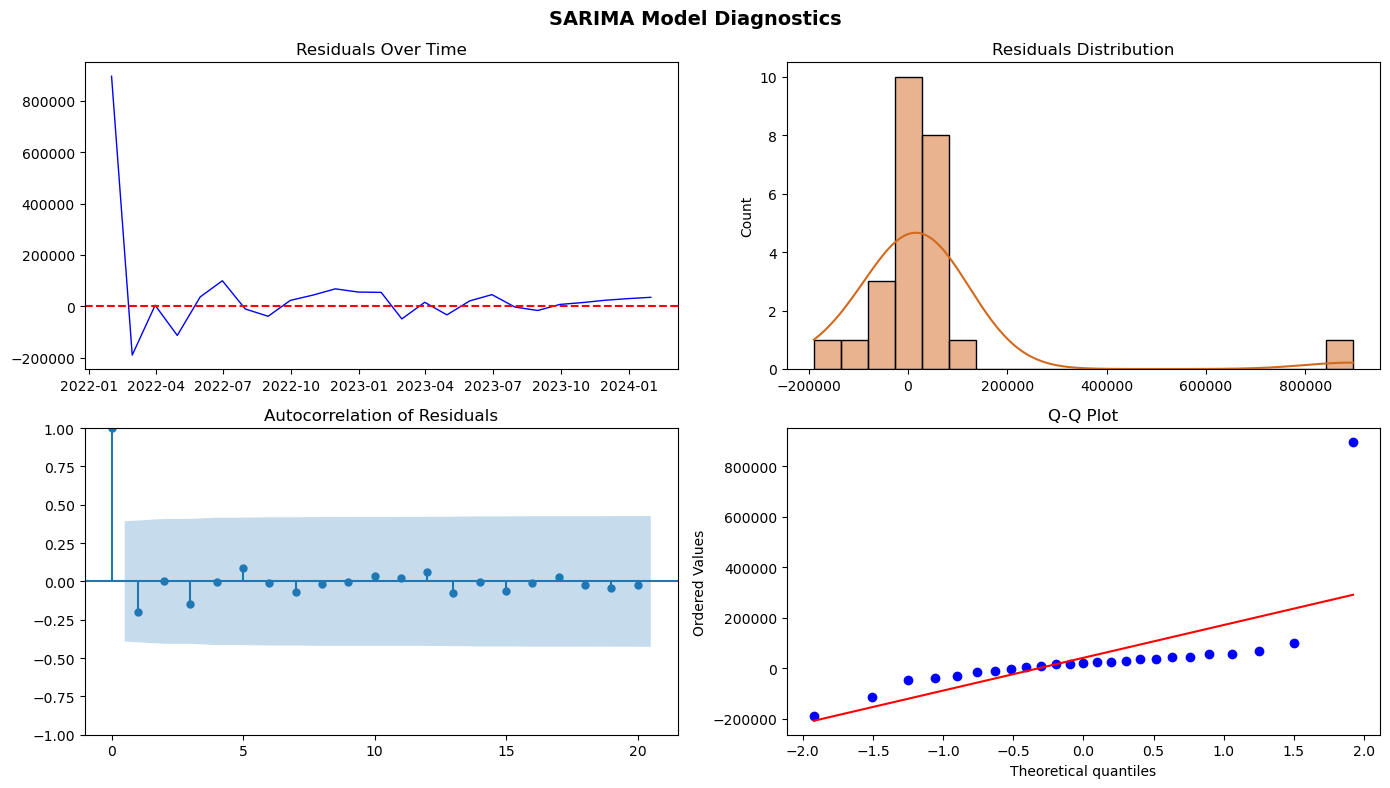

In [116]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# 1. Residuals over time
axes[0, 0].plot(residuals, color='blue', linewidth=1)
axes[0, 0].axhline(y=0, color='red', linestyle='--')
axes[0, 0].set_title('Residuals Over Time')

# 2. Histogram + KDE
import seaborn as sns
sns.histplot(residuals, bins=20, kde=True, color='chocolate', ax=axes[0, 1])
axes[0, 1].set_title('Residuals Distribution')

# 3. ACF plot
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(residuals, lags=20, ax=axes[1, 0])
axes[1, 0].set_title('Autocorrelation of Residuals')

# 4. Q-Q plot
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot')

plt.suptitle('SARIMA Model Diagnostics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()